In [1]:
import os
import mdtraj as md
from utility.Reporting import *
from utility.General import *
from utility.FileManipulations import *

## It all starts with a ligand...

**DrugBank ID** DB04829 \
**Name** Lysergic acid diethylamide\
**Groups** investigational, illicit


Debate continues over the nature and causes of chronic flashbacks. Explanations in terms of LSD physically remaining in the body for months or years after consumption have been discounted by experimental evidence. Some say HPPD is a manifestation of post-traumatic stress disorder, not related to the direct action of LSD on brain chemistry, and varies according to the susceptibility of the individual to the disorder. Many emotionally intense experiences can lead to flashbacks when a person is reminded acutely of the original experience. However, not all published case reports of chronic flashbacks appear to describe an anxious hyper-vigilant state reminiscent of post-traumatic stress disorder.

In [2]:
#obtained as the canonical smiles at https://www.rcsb.org/ligand/7LD
from openff.toolkit import Molecule
ligand = Molecule.from_smiles("CCN(CC)C(=O)[C@H]1CN(C)[C@@H]2Cc3c[nH]c4cccc(C2=C1)c34")

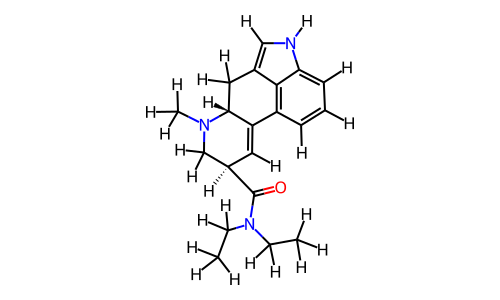

In [3]:
ligand

### Obtain Files from the RCSB

In this case I hvae 4 structures of the 5-HT2B receptor in complex with LSD

In [4]:
#All are 5HT2B with LSD - they are bound to different complexes
lsd_cifs = ['test_data/raw_RCSB/5TVN.cif', #https://www.rcsb.org/structure/5TVN
            'test_data/raw_RCSB/7SRQ.cif', #https://www.rcsb.org/structure/7SRQ
            'test_data/raw_RCSB/7SRR.cif', #https://www.rcsb.org/structure/7SRR
            'test_data/raw_RCSB/7SRS.cif'] #https://www.rcsb.org/structure/7SRS

#The sequence is the same for all of these, load it.  Obtained from UniProt (https://www.uniprot.org/uniprotkb/P41595/entry#sequences)
#WARNING - Assume that the uniprot sequence is in a file that has only two lines, and that the sequence is the second line
with open('test_data/raw_RCSB/htr2b.uniprot_seq.txt', 'r') as f:
    htr2b_seq = f.read().split('\n')[1]

In [5]:
htr2b_seq

'MALSYRVSELQSTIPEHILQSTFVHVISSNWSGLQTESIPEEMKQIVEEQGNKLHWAALLILMVIIPTIGGNTLVILAVSLEKKLQYATNYFLMSLAVADLLVGLFVMPIALLTIMFEAMWPLPLVLCPAWLFLDVLFSTASIMHLCAISVDRYIAIKKPIQANQYNSRATAFIKITVVWLISIGIAIPVPIKGIETDVDNPNNITCVLTKERFGDFMLFGSLAAFFTPLAIMIVTYFLTIHALQKKAYLVKNKPPQRLTWLTVSTVFQRDETPCSSPEKVAMLDGSRKDKALPNSGDETLMRRTSTIGKKSVQTISNEQRASKVLGIVFFLFLLMWCPFFITNITLVLCDSCNQTTLQMLLEIFVWIGYVSSGVNPLVYTLFNKTFRDAFGRYITCNYRATKSVKTLRKRSSKIYFRNPMAENSKFFKKHGIRNGINPAMYQSPMRLRSSTIQSSSIILLDTLLLTENEGDKTEEQVSYV'

In [6]:
for lsdcif in lsd_cifs:
    print(lsdcif)
    print(report_chain_information(md.load(lsdcif)))

test_data/raw_RCSB/5TVN.cif
2026-03-07 21:12:57.656383://Begin Reporting Chain Information
2026-03-07 21:12:57.656527://	chainID=A chainIndex=0 N_atoms=2939 N_residues=393
2026-03-07 21:12:57.656611://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:12:57.656616://	chainID=B chainIndex=1 N_atoms=24 N_residues=1
2026-03-07 21:12:57.656620://	Unique Residues in Chain 7LD
2026-03-07 21:12:57.656624://	chainID=C chainIndex=2 N_atoms=28 N_residues=1
2026-03-07 21:12:57.656627://	Unique Residues in Chain CLR
2026-03-07 21:12:57.656630://	chainID=D chainIndex=3 N_atoms=19 N_residues=1
2026-03-07 21:12:57.656632://	Unique Residues in Chain OLC
2026-03-07 21:12:57.656635://	chainID=E chainIndex=4 N_atoms=7 N_residues=1
2026-03-07 21:12:57.656638://	Unique Residues in Chain PEG
2026-03-07 21:12:57.656640://	chainID=F chainIndex=5 N_atoms=5 N_residues=1
2026-03-07 21:12:57.656643://	Unique Residues in Chain PO4
2026-03-07 21:1

/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/mdtraj/formats/pdbx/pdbx.py:183: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


2026-03-07 21:12:58.546112://Begin Reporting Chain Information
2026-03-07 21:12:58.546223://	chainID=A chainIndex=0 N_atoms=1713 N_residues=225
2026-03-07 21:12:58.546271://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:12:58.546406://	chainID=B chainIndex=1 N_atoms=2518 N_residues=338
2026-03-07 21:12:58.546481://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:12:58.546506://	chainID=C chainIndex=2 N_atoms=363 N_residues=53
2026-03-07 21:12:58.546519://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU HIS ILE LEU LYS MET PHE PRO SER THR TYR VAL
2026-03-07 21:12:58.546619://	chainID=D chainIndex=3 N_atoms=1704 N_residues=229
2026-03-07 21:12:58.546665://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:12:58.546795://	chainID=E chainIndex=4 N_atoms=2072 N_residues=274
20

#### Now is a good time to visually analyze the CIFs in Chimera

**5TVN**: Chimera Report chain A for both, mdtraj reports chain index 0, and 1\
N-Term: GLU 41 (Could be Trimmed to GLY 51)\
C-Term: ARG 400\
Missing Loop: THR 197 - ASN 201\
Missing Loop: GLU 1049 - PRO 1056

**7SRQ**: Chimera reports chain R for both, mdtraj reports chain index 0, 2\
N-Term: TRP 56\
C-Term: TYR 394\
Missing Loop: PRO 160 - SER 168\
Missing Loop: ALA 243 - ALA 322

**7SRR**: Chimera reports chain R for both (R is 274 residues),\
    selection matches chains 4, 5 from mdtraj printing above \
N-Term: TRP 56\
C-Term: ILE 395\
Missing Loop: ALA 248 - THR 315

**7SRS**: Chimera report chain R, (289 res, 2234 atom),\
    selection matches index 2, 7 from print above\
N-Term: TRP 56\
C-Term: CYS 397\
Missing Loop: SER 251 - ARG 313



In [7]:
chains2keep = [{"protein":'chainid 0', "ligand": 'chainid 1'},
               {"protein":'chainid 0', "ligand": 'chainid 2'},
               {"protein":'chainid 4', "ligand": 'chainid 5'},
               {"protein":'chainid 2', "ligand": 'chainid 7'}]

In [8]:
lsd_pdbs = [cif2pdb(lsdcif) for lsdcif in lsd_cifs]

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is 5TVN)

1 molecule converted
*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is 7SRQ)

1 molecule converted
*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is 7SRR)

1 molecule converted
*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is 7SRS)

1 molecule converted


In [9]:
working_direc = './Test_Work'

save_dir = os.path.join(working_direc, 'input_pdbs')
ensure_exists(save_dir)

#Review the output and set to true if good
should_save = True

for lsdcif, selection in zip(lsd_pdbs, chains2keep):
    print(lsdcif)
    name = os.path.basename(lsdcif).split('.')[0]
    rcsb = md.load(lsdcif)
    p_traj = slice_select(rcsb, selection['protein'])
    print(report_chain_information(p_traj))
    l_traj = slice_select(rcsb, selection['ligand'])
    print(report_chain_information(l_traj))
    comp_traj = slice_select(rcsb, f"{selection['protein']} or {selection['ligand']}")
    print(report_chain_information(comp_traj))

    if should_save:
        p_traj.save_pdb(os.path.join(save_dir, f"{name}_protein.mdtraj.pdb"))
        l_traj.save_pdb(os.path.join(save_dir, f"{name}_ligand.mdtraj.pdb"))
        #comp_traj.save_pdb(os.path.join(save_dir, f"{name}_complex.mdtraj.pdb"))

test_data/raw_RCSB/5TVN.obabel.pdb
2026-03-07 21:13:03.469300://Begin Reporting Chain Information
2026-03-07 21:13:03.469351://	chainID=A chainIndex=0 N_atoms=2939 N_residues=393
2026-03-07 21:13:03.469401://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:13:03.473870://Begin Reporting Chain Information
2026-03-07 21:13:03.473879://	chainID=B chainIndex=0 N_atoms=24 N_residues=1
2026-03-07 21:13:03.473883://	Unique Residues in Chain 7LD
2026-03-07 21:13:03.489072://Begin Reporting Chain Information
2026-03-07 21:13:03.489118://	chainID=A chainIndex=0 N_atoms=2939 N_residues=393
2026-03-07 21:13:03.489169://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:13:03.489172://	chainID=B chainIndex=1 N_atoms=24 N_residues=1
2026-03-07 21:13:03.489175://	Unique Residues in Chain 7LD
test_data/raw_RCSB/7SRQ.obabel.pdb
2026-03-07 21:13:03.558793://Begin Re

/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:214: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


test_data/raw_RCSB/7SRR.obabel.pdb
2026-03-07 21:13:04.085860://Begin Reporting Chain Information
2026-03-07 21:13:04.085905://	chainID=E chainIndex=0 N_atoms=2072 N_residues=274
2026-03-07 21:13:04.085941://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:13:04.093041://Begin Reporting Chain Information
2026-03-07 21:13:04.093050://	chainID=F chainIndex=0 N_atoms=24 N_residues=1
2026-03-07 21:13:04.093054://	Unique Residues in Chain 7LD
2026-03-07 21:13:04.108569://Begin Reporting Chain Information
2026-03-07 21:13:04.108604://	chainID=E chainIndex=0 N_atoms=2072 N_residues=274
2026-03-07 21:13:04.108638://	Unique Residues in Chain ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL
2026-03-07 21:13:04.108642://	chainID=F chainIndex=1 N_atoms=24 N_residues=1
2026-03-07 21:13:04.108644://	Unique Residues in Chain 7LD
test_data/raw_RCSB/7SRS.obabel.pdb
2026-03-07 21:13:04.589300://Begin Re

In [10]:
sorted(glob.glob('Test_Work/input_pdbs/*.pdb'))

['Test_Work/input_pdbs/5TVN_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/5TVN_protein.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRQ_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRQ_protein.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRR_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRR_protein.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRS_ligand.mdtraj.pdb',
 'Test_Work/input_pdbs/7SRS_protein.mdtraj.pdb']

### Repair and Prep the Proteins

In [11]:
from RepairProtein.RepairProtein import RepairProtein

In [12]:
alphafold3 = cif2pdb('test_data/alphafold3/fold_htr2b_model_0.cif')

*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is 50b546f81e3dab79)

1 molecule converted


In [13]:
fasta_fn = write_FASTA(htr2b_seq, '5HT2B', 'Test_Work/input_pdbs/5HT2B.uniprot.fasta')
loops = {'5TVN':[[197, 201], [248,313]],
         '7SRQ':[[160,168],[243,322]],
         '7SRR':[[248, 315]],
         '7SRS':[[251, 313]]}
for name in loops.keys():
    modeller_dir = os.path.join(working_direc, 'repair', name)
    if not os.path.isdir(modeller_dir):
        os.makedirs(modeller_dir)
    
    rp = RepairProtein(pdb_fn = f'Test_Work/input_pdbs/{name}_protein.mdtraj.pdb',
                       fasta_fn=fasta_fn,
                       working_dir=modeller_dir)

    rp.run(pdb_out_fn=f'{name}_repaired.modeller.pdb',
           secondary_template_pdb=alphafold3, 
           tails=[56, 394], #Lowest common between all structures i have to test
           loops=loops[name],
           verbose=True)

03/07/2026 21:13:36//Welcome to RepairProtein
03/07/2026 21:13:36//Protein to repair: Test_Work/input_pdbs/5TVN_protein.mdtraj.pdb
03/07/2026 21:13:36//Template sequence: Test_Work/input_pdbs/5HT2B.uniprot.fasta
03/07/2026 21:13:36//Modeller intermediates will be written to: ./Test_Work/repair/5TVN



 CYCLIC = False 



The following 15 residues contain 6-membered rings with poor geometries
after transfer from templates. Rebuilding rings from internal coordinates:
   <Residue 87:A (type TYR)>
   <Residue 92:A (type PHE)>
   <Residue 133:A (type PHE)>
   <Residue 154:A (type TYR)>
   <Residue 214:A (type PHE)>
   <Residue 217:A (type PHE)>
   <Residue 226:A (type PHE)>
   <Residue 237:A (type TYR)>
   <Residue 330:A (type PHE)>
   <Residue 331:A (type PHE)>
   <Residue 333:A (type PHE)>
   <Residue 340:A (type PHE)>
   <Residue 380:A (type TYR)>
   <Residue 383:A (type PHE)>
   <Residue 399:A (type TYR)>
0 atoms in HETATM/BLK residues constrained
to protein atoms within 2.30 angstroms


/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(





 CYCLIC = False 



The following 13 residues contain 6-membered rings with poor geometries
after transfer from templates. Rebuilding rings from internal coordinates:
   <Residue 56:A (type TRP)>
   <Residue 92:A (type PHE)>
   <Residue 133:A (type PHE)>
   <Residue 154:A (type TYR)>
   <Residue 217:A (type PHE)>
   <Residue 220:A (type PHE)>
   <Residue 226:A (type PHE)>
   <Residue 237:A (type TYR)>
   <Residue 330:A (type PHE)>
   <Residue 331:A (type PHE)>
   <Residue 340:A (type PHE)>
   <Residue 380:A (type TYR)>
   <Residue 394:A (type TYR)>
0 atoms in HETATM/BLK residues constrained
to protein atoms within 2.30 angstroms
and protein CA atoms within 10.00 angstroms
0 atoms in residues without defined topology
constrained to be rigid bodies

>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
5HT2B.B99990001.pdb           9727.30273

698 atoms selected for loop refinement
>> Model assessment by DOPE pote

/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(





 CYCLIC = False 



The following 15 residues contain 6-membered rings with poor geometries
after transfer from templates. Rebuilding rings from internal coordinates:
   <Residue 56:A (type TRP)>
   <Residue 92:A (type PHE)>
   <Residue 117:A (type PHE)>
   <Residue 133:A (type PHE)>
   <Residue 154:A (type TYR)>
   <Residue 217:A (type PHE)>
   <Residue 226:A (type PHE)>
   <Residue 237:A (type TYR)>
   <Residue 330:A (type PHE)>
   <Residue 331:A (type PHE)>
   <Residue 333:A (type PHE)>
   <Residue 340:A (type PHE)>
   <Residue 380:A (type TYR)>
   <Residue 383:A (type PHE)>
   <Residue 394:A (type TYR)>
0 atoms in HETATM/BLK residues constrained
to protein atoms within 2.30 angstroms
and protein CA atoms within 10.00 angstroms
0 atoms in residues without defined topology
constrained to be rigid bodies

>> Summary of successfully produced models:
Filename                          molpdf
----------------------------------------
5HT2B.B99990001.pdb          10021.33105

530 atoms s

/home/exouser/miniconda3/envs/chimpss/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:472: UserWarning: PDB file contained CONECT record to TER entry. These are not included in bonds.
  warnings.warn(


03/07/2026 21:21:44//Moved protein from 36.00913344180645 to 25.39950795862651
03/07/2026 21:21:44//Protein Repaired. Output written to: 7SRR_repaired.modeller.pdb
03/07/2026 21:21:44//Welcome to RepairProtein
03/07/2026 21:21:44//Protein to repair: Test_Work/input_pdbs/7SRS_protein.mdtraj.pdb
03/07/2026 21:21:44//Template sequence: Test_Work/input_pdbs/5HT2B.uniprot.fasta
03/07/2026 21:21:44//Modeller intermediates will be written to: ./Test_Work/repair/7SRS



 CYCLIC = False 



The following 12 residues contain 6-membered rings with poor geometries
after transfer from templates. Rebuilding rings from internal coordinates:
   <Residue 56:A (type TRP)>
   <Residue 92:A (type PHE)>
   <Residue 133:A (type PHE)>
   <Residue 154:A (type TYR)>
   <Residue 217:A (type PHE)>
   <Residue 226:A (type PHE)>
   <Residue 237:A (type TYR)>
   <Residue 330:A (type PHE)>
   <Residue 331:A (type PHE)>
   <Residue 333:A (type PHE)>
   <Residue 340:A (type PHE)>
   <Residue 394:A (type TYR)>
0 atoms 

In [13]:
raise Exception("STOPSTOPSTOPSTOPSTOP")

NameError: name 'Excption' is not defined

In [ ]:
def renumber_pdb(pdb_file):
    """
    For a pdb file containing a section that is not number correctly, possibly containing a loop
    """
    with open(

In [ ]:
f = open('Test_Work/input_pdbs/5TVN_protein.mdtraj.pdb', 'r')
lines = f.read().split('\n')
f.close()

In [ ]:
all_seqs = [int(line[22:26]) for line in lines if line.startswith('ATOM') or line.startswith('HETATM')]
res_seq = []
for seq in all_seqs:
    if seq not in res_seq:
        res_seq.append(seq)

In [ ]:
test1 = np.arange(21, 290) #Easy
test2 = np.concatenate((np.arange(3,6),np.arange(35,150),np.arange(167,300))) #Medium
test3 = res_seq #hardest

In [ ]:
test1, test2, test3

In [ ]:
# import numpy as np

# def discover_manifold(ints, n_consistent=10, n_stop=20):
#     """
#     Discover the primary manifold of a sorted array of integers, to be declared the true starting and ending position,
#     a change of +/- 1 must be consistent from that position for at least n_consistent steps.

#     Stop if the starting position is not found within the first n_stop positions
#     """
#     #starting
#     index = 0
#     seq_runs = False
#     while not seq_runs:
#         first_seq = ints[index]
#         check_seqs = np.arange(first_seq, first_seq+n_consistent)
#         seq_runs = False not in [(seq == check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[index:index+n_consistent], check_seqs)]
#         if seq_runs:
#             break
#         else:
#             print(seq_runs)
#             index += 1
#             if index == n_stop:
#                 raise Exception('TOO FAR')
    
#     starting_seq = ints[index]
    
#     #Repeat, backwards
#     index = 0
#     seq_runs = False
    
#     while not seq_runs:
#         first_seq = ints[::-1][index]
#         check_seqs = np.arange(first_seq-n_consistent+1, first_seq+1)[::-1]
#         #print([(seq,check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[::-1][index:index+n_consistent], check_seqs)])
#         #print([(seq == check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[::-1][index:index+n_consistent], check_seqs)])
#         seq_runs = False not in [(seq == check_seq) for i, seq, check_seq in zip(np.arange(n_consistent), ints[::-1][index:index+n_consistent], check_seqs)]
#         #print(seq_runs)
#         if seq_runs:
#             break
#         else:
#             print(seq_runs)
#             index += 1
#             if index == n_stop:
#                 raise Exception('TOO FAR')
    
#     ending_seq = ints[::-1][index]
#     return int(starting_seq), int(ending_seq)


# def manifold_accuracy(ints):
#     """
#     return an array, [index, #position on the suggested manifold
#                       value, #Current numerical value in the array
#                       suggested_value, #value according to the manifold start/stop
#     """

#     starting_elem, ending_elem = discover_manifold(ints)
#     starting_index, ending_index = ints.index(starting_elem), ints.index(ending_elem)
#     extra_positions = len(ints) + starting_index - ending_index - 1
#     suggested_starting_element = starting_elem - starting_index
#     suggested_ending_element = ending_elem + (len(ints) - ending_index - 1)
#     suggested_manifold = np.arange(suggested_starting_element, suggested_ending_element)

#     suggested_mapping = np.empty((suggested_manifold.shape[0], 3))
#     suggested_mapping[:, 0] = suggested_manifold
#     suggested_mapping[:starting_index, 1] = ints[:starting_index]
#     return suggested_mapping
    
#     # #Discover potential missing elements
#     # for i, value in enumerate(ints[starting_index:]):
#     #     if value == suggested_mapping[i+starting_index]:
#     #         suggested_mapping
        
        

    
    

In [ ]:
np.arange(249, 312).shape, np.arange(1001, 1106).shape

In [ ]:
#Detect numerical stability, at least 7 in a row
print(discover_manifold(test1))
print(discover_manifold(test2))
print(discover_manifold(test3))

In [ ]:
manifold_accuracy(list(test1))

In [ ]:
lines[69][17:20], lines[69][21:22], lines[69][23:26]